EDA кроп датасета

In [ ]:
split_counts = df_crops["split"].value_counts().rename_axis("split").reset_index(name="count")
split_counts["percent"] = split_counts["count"] / split_counts["count"].sum() * 100
split_counts

,split,count,percent
0,train,6211,71.064073
1,val,1744,19.954233
2,test,785,8.981693


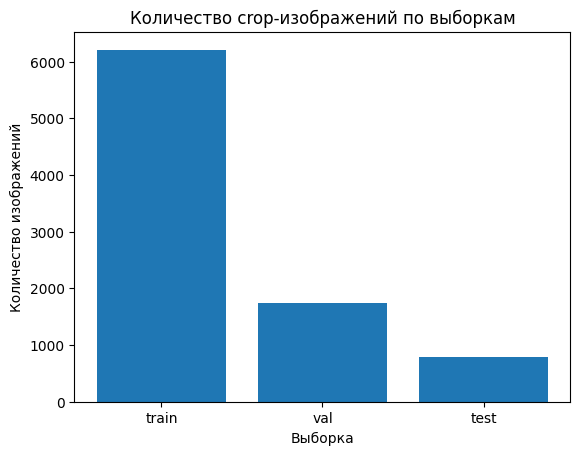

In [ ]:
plt.bar(split_counts["split"], split_counts["count"])
plt.title("Количество crop-изображений по выборкам")
plt.xlabel("Выборка")
plt.ylabel("Количество изображений")
plt.show()

In [ ]:
class_table = pd.crosstab(df_crops["class_name"],df_crops["split"])
class_table["total"] = class_table.sum(axis=1)
class_table["percent_total"] = round(class_table["total"] / class_table["total"].sum() * 100, 2)
class_table.sort_values("total", ascending=False)

split,test,train,val,total,percent_total
class_name,,,,,
scratch,307,2560,728,3595,41.13
dent,236,1806,501,2543,29.10
crack,70,651,177,898,10.27
lamp_broken,69,494,141,704,8.05
glass_shatter,71,475,135,681,7.79
tire_flat,32,225,62,319,3.65


In [ ]:
class_share_by_split = class_table[["train", "val", "test"]].copy()
for split in ["train", "val", "test"]:
    class_share_by_split[split] = round(class_share_by_split[split] / class_share_by_split[split].sum() * 100, 2)
class_share_by_split

split,train,val,test
class_name,,,
crack,10.48,10.15,8.92
dent,29.08,28.73,30.06
glass_shatter,7.65,7.74,9.04
lamp_broken,7.95,8.08,8.79
scratch,41.22,41.74,39.11
tire_flat,3.62,3.56,4.08


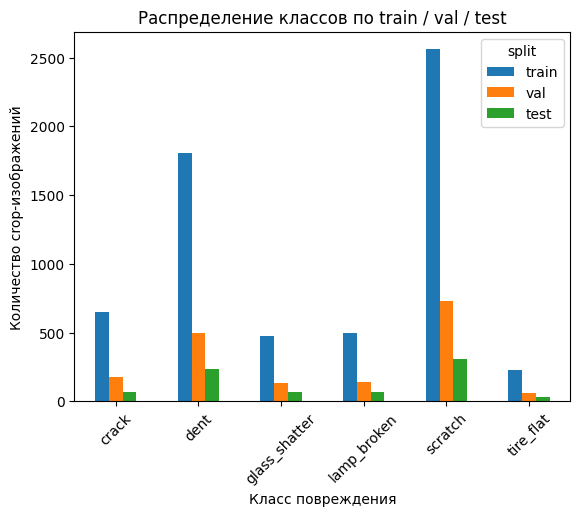

In [ ]:
class_table[["train", "val", "test"]].plot(kind="bar")
plt.title("Распределение классов по train / val / test")
plt.xlabel("Класс повреждения")
plt.ylabel("Количество crop-изображений")
plt.xticks(rotation=45)
plt.show()

In [ ]:
train_counts = df_crops[df_crops["split"] == "train"]["class_name"].value_counts()
imbalance_ratio = train_counts.max() / train_counts.min()
print("Самый частый класс в train:", train_counts.idxmax(), train_counts.max())
print("Самый редкий класс в train:", train_counts.idxmin(), train_counts.min())
print("Дизбаланс классов:", round(imbalance_ratio, 2))

Самый частый класс в train: scratch 2560
Самый редкий класс в train: tire_flat 225
Дизбаланс классов: 11.38


In [ ]:
size_path = PROCESSED_DIR / "crop_sizes.csv"
if size_path.exists():
    df_sizes = pd.read_csv(size_path)
else:
    rows = []
    for row in tqdm(df_crops.itertuples(), total=len(df_crops), desc="Reading image sizes"):
        img = Image.open(row.local_path)
        width, height = img.size
        rows.append({
            "split": row.split,
            "class_name": row.class_name,
            "width": width,
            "height": height,
            "area": width * height
        })
    df_sizes = pd.DataFrame(rows)
    df_sizes.to_csv(size_path, index=False)
df_sizes.describe()

,width,height
count,8740.000000,8740.000000
mean,438.859268,325.189474
std,287.064364,209.912052
min,10.000000,9.000000
25%,199.000000,148.000000
50%,381.000000,282.000000
75%,641.000000,482.250000
max,1000.000000,1000.000000


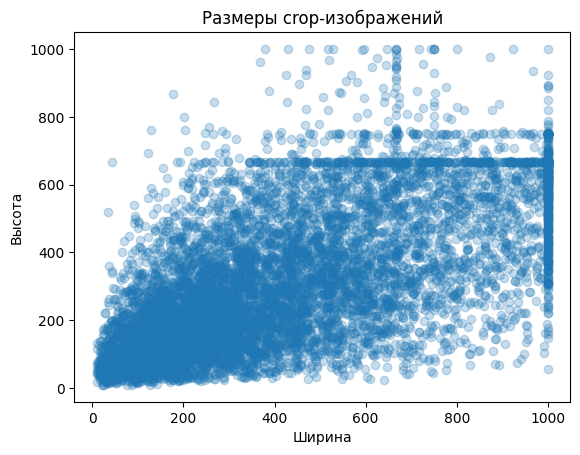

In [ ]:
plt.scatter(df_sizes["width"], df_sizes["height"], alpha=0.25)
plt.title("Размеры crop-изображений")
plt.xlabel("Ширина")
plt.ylabel("Высота")
plt.show()

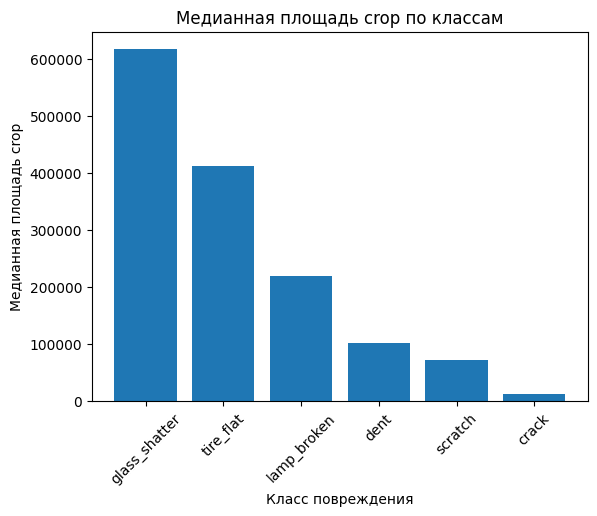

In [ ]:
df_sizes["area"] = df_sizes["width"] * df_sizes["height"]
class_area = (df_sizes.groupby("class_name")["area"].median().sort_values(ascending=False).reset_index())
plt.bar(class_area["class_name"], class_area["area"])
plt.title("Медианная площадь crop по классам")
plt.xlabel("Класс повреждения")
plt.ylabel("Медианная площадь crop")
plt.xticks(rotation=45)
plt.show()

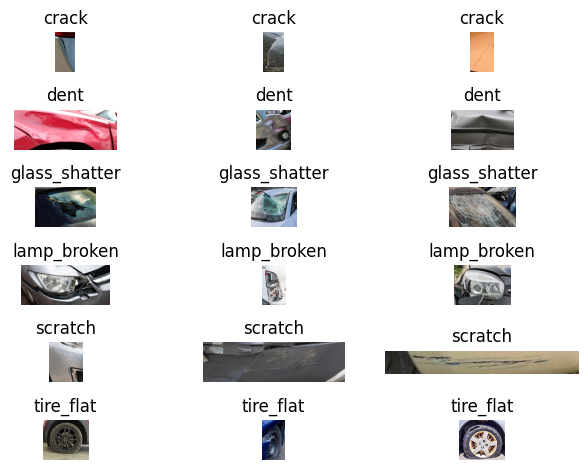

In [ ]:
classes = sorted(df_crops["class_name"].unique())
plot_id = 1
for class_name in classes:
    examples = df_crops[df_crops["class_name"] == class_name].sample(3, random_state=42)
    for row in examples.itertuples():
        img = Image.open(row.local_path).convert("RGB")
        plt.subplot(len(classes), 3, plot_id)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plot_id += 1
plt.tight_layout()
plt.show()